In [12]:
import os
import numpy as np
import arviz as az
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import ustreasurycurve as ustcurve

from Library.Utility import UST_TENOR_MAP
from Library.OptionPricerBSM1973 import BlackScholesMertonPut
from Library.SkewCalibrationHeston1993 import HestonSkewCalibration, feller_condition
from scipy.optimize import minimize
from nelson_siegel_svensson.calibrate import calibrate_nss_ols

az.style.use("arviz-darkgrid")

DATA_PATH_STR = r"/Users/josephyi/Library/Mobile Documents/com~apple~CloudDocs/Data/Implied Volatility"
UND_TICKERS_DICT = {'systematic': '^SPX', 'idiosyncratic': ['COIN']}
DIVIDEND_YIELDS = {'^SPX': 1.25}
EXPIRY_MAP = {0: 11, 1: 10, 2: 9, 3: 8, 4: 7}

In [2]:
valuation_date_array = pd.bdate_range('2025-03-18', '2025-04-17')
# https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics?data=yield%27
rates_data_df = ustcurve.nominalRates(valuation_date_array[0].strftime("%Y-%m-%d"), valuation_date_array[-1].strftime("%Y-%m-%d")).set_index('date')
rates_data_df = pd.DataFrame(index=pd.date_range(rates_data_df.index.min(), rates_data_df.index.max())).join(rates_data_df).ffill(axis=1).bfill(axis=1).ffill().bfill()
rates_tenors = np.array([UST_TENOR_MAP[x] for x in rates_data_df.columns])
rates_data_df.head()

,1m,1.5m,2m,3m,4m,6m,1y,2y,3y,5y,7y,10y,20y,30y
2025-03-18,4.37,4.35,4.33,4.34,4.29,4.29,4.13,4.04,4.01,4.07,4.18,4.29,4.61,4.58
2025-03-19,4.37,4.34,4.32,4.33,4.30,4.29,4.10,3.99,3.95,4.03,4.14,4.25,4.58,4.56
2025-03-20,4.36,4.34,4.34,4.33,4.29,4.27,4.06,3.95,3.93,4.01,4.12,4.24,4.57,4.55
2025-03-21,4.36,4.33,4.33,4.33,4.29,4.26,4.04,3.94,3.92,4.00,4.12,4.25,4.60,4.59
2025-03-22,4.36,4.33,4.33,4.33,4.29,4.26,4.04,3.94,3.92,4.00,4.12,4.25,4.60,4.59


In [3]:
PATH_STR = os.path.join(DATA_PATH_STR, UND_TICKERS_DICT['systematic'].split("^")[-1])

mkt_vol_df1 = pd.concat([pd.read_csv(os.path.join(PATH_STR, file)) for file in sorted(os.listdir(PATH_STR))])

mkt_vol_df2 = []
for underlying_name in UND_TICKERS_DICT['idiosyncratic']:

    PATH_STR = os.path.join(DATA_PATH_STR, underlying_name)

    tmp_df = pd.concat([pd.read_csv(os.path.join(PATH_STR, file)) for file in sorted(os.listdir(PATH_STR))])

    mkt_vol_df2.append(tmp_df)

mkt_vol_df2 = pd.concat(mkt_vol_df2)
mkt_vol_df = pd.concat([mkt_vol_df1, mkt_vol_df2])

mkt_vol_df.quote_date = pd.to_datetime(mkt_vol_df.quote_date)
mkt_vol_df.expiration = pd.to_datetime(mkt_vol_df.expiration)

mkt_vol_df['iEXPIRY'] = (mkt_vol_df.expiration - mkt_vol_df.quote_date).dt.days
mkt_vol_df['dEXPIRY'] = mkt_vol_df.iEXPIRY / 365

mkt_vol_df['dUND_PRICE'] = mkt_vol_df.active_underlying_price_1545
mkt_vol_df['dUND_STRIKE'] = mkt_vol_df.strike
mkt_vol_df['dMONEYNESS'] = mkt_vol_df.dUND_STRIKE / mkt_vol_df.dUND_PRICE * 100.
mkt_vol_df['dMKT_IMP_VOL'] = mkt_vol_df.implied_volatility_1545

mask = mkt_vol_df.option_type=='C'
mkt_vol_df['bIS_CALL_OPTION'] = False
mkt_vol_df.loc[mask, 'bIS_CALL_OPTION'] = True

mask  = (mkt_vol_df.trade_volume > 0) & (mkt_vol_df.iEXPIRY > 5) & (mkt_vol_df.dMKT_IMP_VOL > 0)
mkt_vol_df = mkt_vol_df.loc[mask]

mask = (mkt_vol_df.option_type=='P') & (mkt_vol_df.dMONEYNESS <= 100.) & (mkt_vol_df.dMONEYNESS >= 50.)
mkt_vol_df1 = mkt_vol_df.loc[mask]
mask = (mkt_vol_df.option_type=='C') & (mkt_vol_df.dMONEYNESS >= 100.) & (mkt_vol_df.dMONEYNESS <= 150.)
mkt_vol_df2 = mkt_vol_df.loc[mask]

mkt_vol_df = pd.concat([mkt_vol_df1, mkt_vol_df2])

for t in mkt_vol_df.quote_date.unique():
    rate_fitter, _ = calibrate_nss_ols(rates_tenors, rates_data_df.xs(t).to_numpy() / 100)
    mask = (mkt_vol_df.quote_date==t)
    mkt_vol_df.loc[mask, 'dRISK_FREE_RATE'] = mkt_vol_df.loc[mask, 'dEXPIRY'].apply(rate_fitter)

mkt_vol_df['dDIVIDEND_YIELD'] = DIVIDEND_YIELDS[mkt_vol_df.underlying_symbol.iloc[0]] / 100.

vegas = []
for tup in mkt_vol_df.itertuples():
    vega = BlackScholesMertonPut(
        und_price=np.array(tup.dUND_PRICE),
        und_strike=np.array(tup.dUND_STRIKE),
        risk_free_rate=np.array(tup.dRISK_FREE_RATE),
        dividend_yield=np.array(tup.dDIVIDEND_YIELD),
        time_to_expiry=np.array(tup.dEXPIRY)
    ).vega(np.array(tup.dMKT_IMP_VOL)) / 100.
    vegas.append(vega[0, 0])

mkt_vol_df['dVEGA'] = vegas

In [4]:
initial_values_systematic = np.array([.25, 3., .25, .5, -.5, .1])

method = 'SLSQP'

bounds_systematic = {
    'dV0': (1e-3, 5.),
    'dKAPPA': (1e-3, 5.),
    'dTHETA': (1e-3, 5.),
    'dSIGMA': (1e-2, 10.),
    'dRHOSV': (-1., 1.),
    'dLAMBD': (-1., 1.)
}

calib_results = {}

In [6]:
systematic_name = UND_TICKERS_DICT['systematic']

for valuation_date in valuation_date_array:

    if valuation_date in mkt_vol_df.quote_date.unique():

        valuation_date_str = valuation_date.strftime("%Y%m%d")

        key = f'{systematic_name}-{valuation_date_str}'

        display('--------')
        display(key)
        display('--------')

        if key in calib_results.keys():
            pass
        else:

            results_ = {}

            T = EXPIRY_MAP[valuation_date.weekday()]

            if (valuation_date >= pd.to_datetime('20250407')) and (valuation_date < pd.to_datetime('20250414')):
                T = T - 1

            mask  = (mkt_vol_df.underlying_symbol==systematic_name)
            mask &= (mkt_vol_df.quote_date==valuation_date)
            mask &= (mkt_vol_df.iEXPIRY==T)
            mask &= (mkt_vol_df.dMONEYNESS >= 50.)
            mask &= (mkt_vol_df.dMONEYNESS <= 150.)

            tmp_df = mkt_vol_df.loc[mask].sort_values('dMONEYNESS')

            vol_fitter = HestonSkewCalibration(
                mkt_imp_vol=tmp_df.dMKT_IMP_VOL.to_numpy(),
                und_price=tmp_df.dUND_PRICE.to_numpy(),
                und_strike=tmp_df.dUND_STRIKE.to_numpy(),
                risk_free_rate=tmp_df.dRISK_FREE_RATE.to_numpy(),
                dividend_yield=tmp_df.dDIVIDEND_YIELD.to_numpy(),
                time_to_expiry=tmp_df.dEXPIRY.to_numpy(),
                is_call_option=tmp_df.bIS_CALL_OPTION.to_numpy(),
                option_weights=tmp_df.dVEGA.to_numpy() / tmp_df.dVEGA.sum()
            )

            minimizer_results = minimize(
                vol_fitter.target,
                x0=initial_values_systematic,
                method=method,
                bounds=bounds_systematic.values(),
                tol=1e-6,
                options={'maxiter': 1e4},
                constraints=({'type': 'ineq', 'fun': feller_condition})
            )

            display(minimizer_results)

            results_[valuation_date_str] = minimizer_results

            calib_results[key] = minimizer_results

'--------'

'^SPX-20250318'

'--------'

/Users/josephyi/anaconda3/envs/liquidity/lib/python3.10/site-packages/scipy/integrate/_quadpack_py.py:611: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagse(func,a,b,args,full_output,epsabs,epsrel,limit)
/Users/josephyi/PycharmProjects/mkt-depth-n-resiliency/Library/SkewCalibrationHeston1993.py:223: RuntimeWarning: some derivatives were zero
  mod_iv_put = newton(
/Users/josephyi/PycharmProjects/mkt-depth-n-resiliency/Library/SkewCalibrationHeston1993.py:168: RuntimeWarning: some derivatives were zero
  mod_iv_call = newton(
/Users/josephyi/anaconda3/envs/liquidity/lib/python3.10/site-packages/scipy/optimize/_zeros_py.py:427: RuntimeWarning: overflow encountered in divide
  dp = fval[nz_der] / fder[nz_der]
/Users/josephyi/anaconda3/envs/liquidity/lib/python3.10/site-packages/scipy/optimize/_zeros_py.py:430: RuntimeWarning: invalid value encountered in divide
  dp = dp / (1.0 - 0.5 * dp * fder2[nz_der] / fder[nz_der])


 message: Singular matrix E in LSQ subproblem
 success: False
  status: 5
     fun: 0.015714828407394573
       x: [ 1.000e-03  2.999e+00  2.322e-01  5.006e-01 -4.999e-01
            1.006e-01]
     nit: 3
     jac: [ 1.115e+07 -1.027e+05        nan  6.845e+09  9.770e+08
           -3.462e+05]
    nfev: 22
    njev: 3

...

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.000997148626461056
       x: [ 1.022e-01  2.999e+00  2.333e-01  7.006e-01 -6.789e-01
            9.987e-02]
     nit: 8
     jac: [ 1.024e+03 -2.491e+01  5.084e+02  3.193e+00  6.556e+01
            4.869e+01]
    nfev: 69
    njev: 8

'--------'

'^SPX-20250417'

'--------'

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.035879076085809966
       x: [ 3.342e-02  3.000e+00  2.428e-01  5.001e-01 -4.998e-01
            1.006e-01]
     nit: 2
     jac: [ 2.161e+07  1.069e+08 -1.581e+03  3.705e+07  9.573e+02
            3.855e+10]
    nfev: 25
    njev: 2

In [14]:
valuation_date = '20250409'
name = 'COIN'
T = EXPIRY_MAP[pd.to_datetime(valuation_date).weekday()]
if (pd.to_datetime(valuation_date) >= pd.to_datetime('20250407')) and (pd.to_datetime(valuation_date) < pd.to_datetime('20250414')):
    T = T - 1
mask  = (mkt_vol_df.underlying_symbol==name)
mask &= (mkt_vol_df.quote_date==valuation_date) & (mkt_vol_df.iEXPIRY==T) & (mkt_vol_df.dMONEYNESS >= 50.) & (mkt_vol_df.dMONEYNESS <= 150.)
tmp_df = mkt_vol_df.loc[mask].sort_values('dMONEYNESS')
tmp_df.dMKT_IMP_VOL *= 100.
expiry_date = tmp_df.expiration.iloc[0]

In [15]:
vol_fitter = HestonSkewCalibration(
    mkt_imp_vol=tmp_df.dMKT_IMP_VOL.to_numpy() / 100.,
    und_price=tmp_df.dUND_PRICE.to_numpy(),
    und_strike=tmp_df.dUND_STRIKE.to_numpy(),
    risk_free_rate=tmp_df.dRISK_FREE_RATE.to_numpy(),
    dividend_yield=tmp_df.dDIVIDEND_YIELD.to_numpy(),
    time_to_expiry=tmp_df.dEXPIRY.to_numpy(),
    is_call_option=tmp_df.bIS_CALL_OPTION.to_numpy(),
    option_weights=tmp_df.dVEGA.to_numpy() / tmp_df.dVEGA.sum()
)

tmp_df['dMOD_IMP_VOL'] = vol_fitter.model_vol(x=calib_results[f"{name}-{valuation_date}"].x) * 100.

tmp_df

/Users/josephyi/anaconda3/envs/liquidity/lib/python3.10/site-packages/scipy/integrate/_quadpack_py.py:611: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagse(func,a,b,args,full_output,epsabs,epsrel,limit)


,underlying_symbol,quote_date,root,expiration,strike,option_type,open,high,low,close,...,dEXPIRY,dUND_PRICE,dUND_STRIKE,dMONEYNESS,dMKT_IMP_VOL,bIS_CALL_OPTION,dRISK_FREE_RATE,dDIVIDEND_YIELD,dVEGA,dMOD_IMP_VOL
263,COIN,2025-04-09,COIN,2025-04-17,90.0,P,0.27,0.32,0.10,0.10,...,0.021918,178.965,90.0,50.289163,215.05,False,0.044481,0.0125,0.007157,168.607349
265,COIN,2025-04-09,COIN,2025-04-17,95.0,P,0.10,0.10,0.10,0.10,...,0.021918,178.965,95.0,53.083005,181.62,False,0.044481,0.0125,0.004732,157.279320
267,COIN,2025-04-09,COIN,2025-04-17,96.0,P,0.16,0.16,0.16,0.16,...,0.021918,178.965,96.0,53.641774,195.37,False,0.044481,0.0125,0.007496,155.216949
275,COIN,2025-04-09,COIN,2025-04-17,100.0,P,0.61,0.66,0.08,0.13,...,0.021918,178.965,100.0,55.876847,182.49,False,0.044481,0.0125,0.007643,147.680085
279,COIN,2025-04-09,COIN,2025-04-17,102.0,P,0.22,0.22,0.22,0.22,...,0.021918,178.965,102.0,56.994384,179.98,False,0.044481,0.0125,0.008486,144.342230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,COIN,2025-04-09,COIN,2025-04-17,235.0,C,0.10,0.25,0.09,0.22,...,0.021918,178.965,235.0,131.310591,91.76,True,0.044481,0.0125,0.016344,75.505058
438,COIN,2025-04-09,COIN,2025-04-17,240.0,C,0.10,0.30,0.03,0.17,...,0.021918,178.965,240.0,134.104434,93.10,True,0.044481,0.0125,0.012791,75.637105
440,COIN,2025-04-09,COIN,2025-04-17,245.0,C,0.25,0.25,0.25,0.25,...,0.021918,178.965,245.0,136.898276,97.33,True,0.044481,0.0125,0.011585,75.857044
442,COIN,2025-04-09,COIN,2025-04-17,250.0,C,0.11,0.19,0.02,0.13,...,0.021918,178.965,250.0,139.692119,98.71,True,0.044481,0.0125,0.009201,76.144258


In [20]:
calib_results[f"{name}-{valuation_date}"]

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.0038696059396467375
       x: [ 7.033e-01  3.436e+00  5.000e+00  5.862e+00 -6.121e-01
            7.973e-02]
     nit: 26
     jac: [ 3.322e-04  1.087e-04  6.178e-05 -8.362e-04  7.975e-05
            1.883e-05]
    nfev: 184
    njev: 26

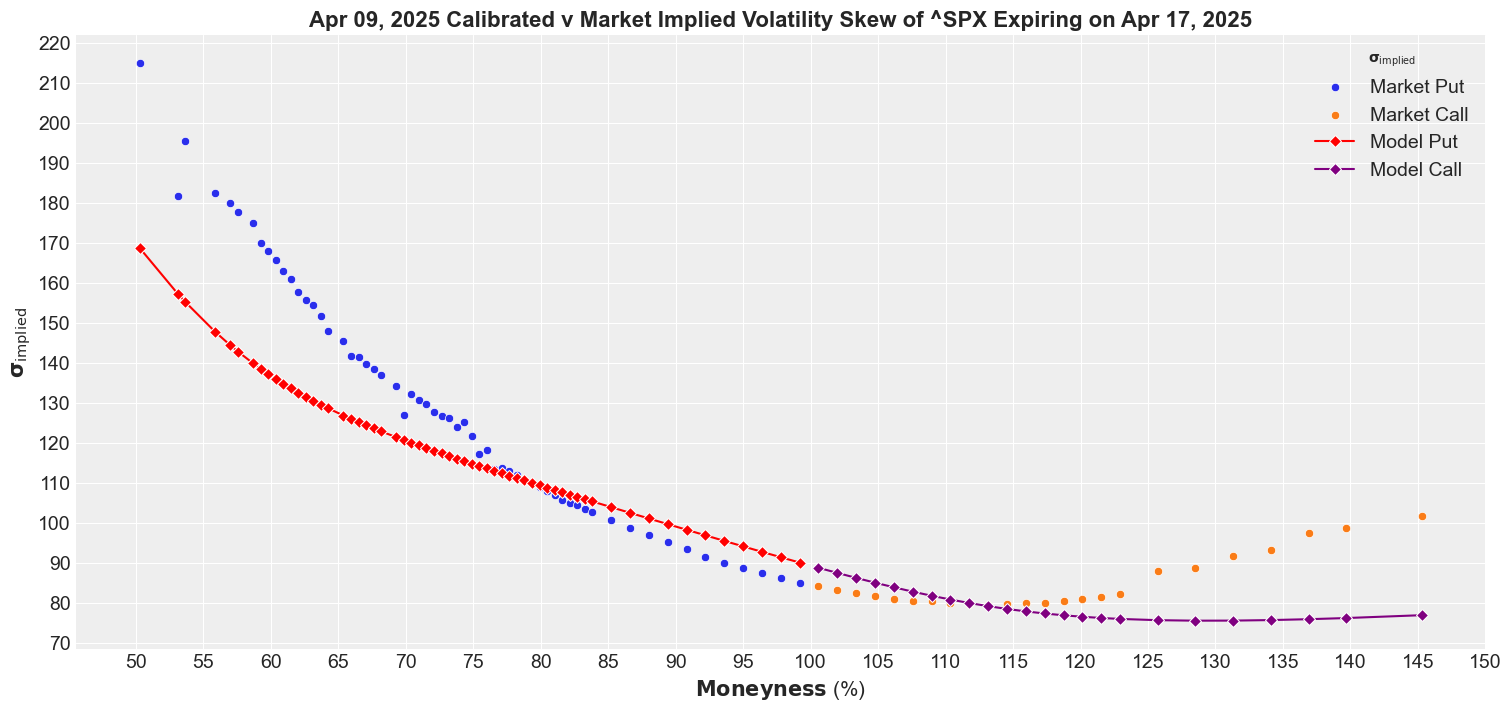

In [18]:
fig, ax = plt.subplots(figsize=(15, 7))

sns.scatterplot(data=tmp_df.loc[~tmp_df.bIS_CALL_OPTION], x='dMONEYNESS', y='dMKT_IMP_VOL', label='Market Put',  ax=ax)
sns.scatterplot(data=tmp_df.loc[tmp_df.bIS_CALL_OPTION],  x='dMONEYNESS', y='dMKT_IMP_VOL', label='Market Call', ax=ax)
sns.lineplot(data=tmp_df.loc[~tmp_df.bIS_CALL_OPTION], x='dMONEYNESS', y='dMOD_IMP_VOL', label='Model Put',  ax=ax, color='r', marker='D')
sns.lineplot(data=tmp_df.loc[tmp_df.bIS_CALL_OPTION],  x='dMONEYNESS', y='dMOD_IMP_VOL', label='Model Call', ax=ax, color='purple', marker='D')

ax.set(xlabel=rf'$\bf Moneyness$ (%)', ylabel=r'$\bf \sigma_{\text{implied}}$')
ax.legend(title=r'$\bf \sigma_{\text{implied}}$')
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(10))
ax.set_title(
    f'{pd.to_datetime(valuation_date, format="%Y%m%d").strftime("%b %d, %Y")} Calibrated v Market Implied Volatility Skew of {systematic_name} ' +
    f'Expiring on {pd.to_datetime(expiry_date, format="%Y%m%d").strftime("%b %d, %Y")}', weight='bold'
)
# plt.savefig(f"SPX_VOL_SKEW_{valuation_date_str}.pdf", dpi=300)
plt.show();

In [19]:
import pickle

file_path = r"/Users/josephyi/PycharmProjects/mkt-depth-n-resiliency/Study/Estimated Parameters QLSQ/heston1993_vol_calibration.pkl"

try:
    with open(file_path, "wb") as file:
        pickle.dump(calib_results, file)
    print(f"Dictionary successfully saved to {file_path}")
except Exception as e:
    print(f"An error occured: {e}")

Dictionary successfully saved to /Users/josephyi/PycharmProjects/mkt-depth-n-resiliency/Study/Estimated Parameters QLSQ/heston1993_vol_calibration.pkl
